# 8.0 Machine Learning Models

**Reference files used:**
- `ReferenceData/state_crosswalk.csv` — canonical state codes, valid-from/to years, bifurcation history  
- `ReferenceData/state_name_audit.csv` — raw state names identified during the audit pass  
- `ReferenceData/state_name_variants.csv` — variant → canonical name lookup (also used in cleanup notebook)

**Filtered inputs expected:**
```
FilteredData/clean_election_results_1951_2019.csv
FilteredData/clean_loksabha_1962_2019.csv
FilteredData/clean_election_results_2024.csv
FilteredData/clean_ref_party_master.csv
FilteredData/features_dataset.csv
```

---
## Imports & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

In [2]:
# ─── Reference files ────────────────────────────────────────────────────────
state_crosswalk     = pd.read_csv('ReferenceData/state_crosswalk.csv')
state_name_audit    = pd.read_csv('ReferenceData/state_name_audit.csv')
state_name_variants = pd.read_csv('ReferenceData/state_name_variants.csv')

# ─── Cleaned election datasets (output of cleanup notebook) ─────────────────
df_1951_2019 = pd.read_csv('FilteredData/clean_election_results_1951_2019.csv')
df_loksabha  = pd.read_csv('FilteredData/clean_loksabha_1962_2019.csv')
df_2024      = pd.read_csv('FilteredData/clean_election_results_2024.csv')
df_party     = pd.read_csv('FilteredData/clean_ref_party_master.csv')
df_features  = pd.read_csv('FilteredData/features_dataset.csv')
# ________________ Additional Datasets_________________________
df_state_gdp  = pd.read_csv('FilteredData/clean_state_gdp_share.csv')
df_literacy_51_11  = pd.read_csv('FilteredData/clean_literacy_1951_2011.csv')

print('Loaded datasets:')
print(f'  clean_election_results_1951_2019 : {df_1951_2019.shape}')
print(f'  clean_loksabha_1962_2019         : {df_loksabha.shape}')
print(f'  clean_election_results_2024      : {df_2024.shape}')
print(f'  clean_ref_party_master           : {df_party.shape}')
print(f'  df_features                      : {df_features.shape}')
print(f'  df_state_gdp                     : {df_state_gdp.shape}')
print(f'  df_literacy_51_11                : {df_literacy_51_11.shape}')

Loaded datasets:
  clean_election_results_1951_2019 : (89840, 19)
  clean_loksabha_1962_2019         : (8047, 15)
  clean_election_results_2024      : (8902, 16)
  clean_ref_party_master           : (10153, 27)
  df_features                      : (89840, 30)
  df_state_gdp                     : (291, 10)
  df_literacy_51_11                : (7, 5)


---

### Dataframes for ML model

In [4]:
df_model = pd.read_csv("Sub Datasets/df_model.csv")
df_model_clean = pd.read_csv("Sub Datasets/df_model_clean.csv")
df_mixed_clean = pd.read_csv("Sub Datasets/df_mixed_clean.csv")
df_logit = pd.read_csv("Sub Datasets/df_logit.csv")
ts_data = pd.read_csv("Sub Datasets/ts_data.csv")
predicted_classes = pd.read_csv("Sub Datasets/predicted_classes.csv")
predicted_probs = pd.read_csv("Sub Datasets/predicted_probes.csv")
predictions_mixed = pd.read_csv("Sub Datasets/predictions_mix.csv")
predictions = pd.read_csv("Sub Datasets/predictions.csv")
df_cv = pd.read_csv("Sub Datasets/df_cv.csv")

# Print shape of each DataFrame
print("df_model:", df_model.shape)
print("df_model_clean:", df_model_clean.shape)
print("df_mixed_clean:", df_mixed_clean.shape)
print("df_logit:", df_logit.shape)
print("ts_data:", ts_data.shape)
print("predicted_classes:", predicted_classes.shape)
print("predicted_probs:", predicted_probs.shape)
print("predictions_mixed:", predictions_mixed.shape)
print("predictions:", predictions.shape)
print("df_cv:", df_cv.shape)

df_model: (90747, 34)
df_model_clean: (4773, 34)
df_mixed_clean: (4773, 34)
df_logit: (63993, 30)
ts_data: (18, 1)
predicted_classes: (63993, 1)
predicted_probs: (63993, 1)
predictions_mixed: (4773, 1)
predictions: (90747, 1)
df_cv: (63993, 30)


---

## 8.1 Supervised learning

### 8.1.1 Random Forest for predicting win/loss

We use Random Forest to predict seat outcomes, but focus on feature importance to understand drivers of electoral change. Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the mode of the classes for classification. By aggregating slightly decorrelated trees, it naturally captures complex, non-linear interactions between variables like lagged vote share and fragmentation without overfitting.

 decision tree splits nodes by minimizing Gini Impurity ($G$). For a node with $C$ classes (win/loss, so $C=2$), where $p_i$ is the probability of an item belonging to class $i$:$$G = 1 - \sum_{i=1}^{C} p_i^2$$The final Random Forest prediction ($\hat{y}$) for an observation $x$ across $B$ trees is the majority vote:$$\hat{y} = \text{mode} \{ h_1(x), h_2(x), \dots, h_B(x) \}$$

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Define features and target
features = ['vote_share_lag1', 'coalition_strength_score', 'fragmentation_index', 'is_incumbent']

# 2. Isolate the ML dataset, replace Infinity with NaN, and drop missing values
df_ml = df_features[features + ['is_winner']].copy()
df_ml = df_ml.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Separate features (X) and target (y)
X = df_ml[features]
y = df_ml['is_winner']

# 4. Split into training and testing sets (stratified to maintain win/loss ratios)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Fit the Random Forest model
# We restrict max_depth to 10 to prevent overfitting and maintain interpretability
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Random Forest successfully fitted on {len(X_train)} training observations!")

Random Forest successfully fitted on 51181 training observations!


### 8.1.2 Gradient Boosting (XGBoost)

Unlike Random Forest which builds trees independently, Extreme Gradient Boosting (XGBoost) builds trees sequentially. Each new tree mathematically targets and corrects the residual errors of the previous sequence of trees. This makes it highly sensitive to marginal, difficult-to-predict constituencies (e.g., extremely close multipolar contests).

At iteration $t$, we seek to add a tree $f_t$ that minimizes the objective function $\mathcal{L}^{(t)}$, which balances the loss function $l$ against a regularization term $\Omega$ (to penalize tree complexity):$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

In [7]:
import xgboost as xgb

# Fit an XGBoost classifier using logistic loss for binary classification
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    objective='binary:logistic',
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### 8.1.3 Hyperparameter tuning

To prevent "black-box" overfitting and ensure the model learns generalizable political patterns rather than memorizing historical anomalies, we systematically restrict the depth and complexity of the trees via hyperparameter tuning using cross-validation.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

# Perform a randomized search over the hyperparameter space
xgb_tuned = RandomizedSearchCV(xgb.XGBClassifier(objective='binary:logistic'), 
                               param_distributions=param_grid, 
                               cv=5, scoring='accuracy', n_iter=10, random_state=42)
xgb_tuned.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` 

---

## 8.2 Unsupervised learning

### 8.2.1 K-Means clustering of states by electoral behavior

We partition India's states into $K$ distinct clusters based on their aggregate democratic behaviors—specifically electoral volatility (Pedersen index), party-system fragmentation (ENP), and voter turnout. This algorithm iteratively shifts cluster centroids to group states with similar political ecosystems.

The algorithm minimizes the within-cluster sum of squared variances ($J$), where $\mu_j$ is the centroid of cluster $C_j$:$$J = \sum_{j=1}^{K} \sum_{x_i \in C_j} || x_i - \mu_j ||^2$$

In [11]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Calculate Average Fragmentation per state
state_frag = df_features.groupby('state_canonical')['fragmentation_index'].mean().reset_index()

# 2. Calculate Pedersen Volatility Index per state
df_features['abs_vote_swing'] = df_features['vote_swing'].abs()
state_volatility = df_features.groupby('state_canonical')['abs_vote_swing'].mean().reset_index()
state_volatility.rename(columns={'abs_vote_swing': 'pedersen_index'}, inplace=True)
state_volatility['pedersen_index'] = state_volatility['pedersen_index'] / 2

# 3. Calculate Average Turnout per state from df_loksabha
state_turnout = df_loksabha.groupby('state_canonical')['Turnout'].mean().reset_index()

# 4. Merge all metrics into a single dataset
state_metrics = pd.merge(state_frag, state_volatility, on='state_canonical', how='inner')
state_metrics = pd.merge(state_metrics, state_turnout, on='state_canonical', how='inner')
state_metrics.set_index('state_canonical', inplace=True)

# 5. CRITICAL FIX: Replace any infinities with NaN, then drop those corrupted rows
state_metrics = state_metrics.replace([np.inf, -np.inf], np.nan).dropna()

# 6. Standardize features to ensure equal weighting in K-Means
scaler = StandardScaler()
state_metrics_scaled = scaler.fit_transform(state_metrics)

# 7. Fit the K-Means algorithm to find 3 distinct regional electoral behaviors
kmeans = KMeans(n_clusters=3, random_state=42)
state_metrics['cluster'] = kmeans.fit_predict(state_metrics_scaled)

print("Clustering successful! Here is a sample of the states and their assigned clusters:")
print(state_metrics.head(10))

Clustering successful! Here is a sample of the states and their assigned clusters:
                   fragmentation_index  pedersen_index    Turnout  cluster
state_canonical                                                           
Arunachal Pradesh             4.187964        3.283333  65.965217        1
Chandigarh                    4.808179        1.663469  62.692857        2
Chhattisgarh                  9.464632        0.160640  63.165909        0
Delhi                         2.279695        1.223068  67.931579        2
Goa                           5.504117        1.074828  59.288889        2
Gujarat                       3.998916        1.241068  54.350262        2
Haryana                       5.708638        1.066981  68.292754        2
Himachal Pradesh              3.914380        2.859519  57.967742        2
Jharkhand                     9.569565        0.801698  60.364286        0
Kerala                        7.327279        1.872841  73.026689        1


### 8.2.2 Hierarchical clustering of election years

To empirically derive "political eras" rather than relying on qualitative historical narratives, we apply agglomerative hierarchical clustering to election years. By measuring the structural similarity of the party system (e.g., national ENP, seat disproportionality) year over year, the algorithm builds a dendrogram connecting closely related elections.

We use Ward's minimum variance method, which merges clusters $A$ and $B$ if the merge minimizes the increase in the total within-cluster variance ($\Delta(A,B)$):$$\Delta(A,B) = \frac{|A||B|}{|A| + |B|} || \mu_A - \mu_B ||^2$$

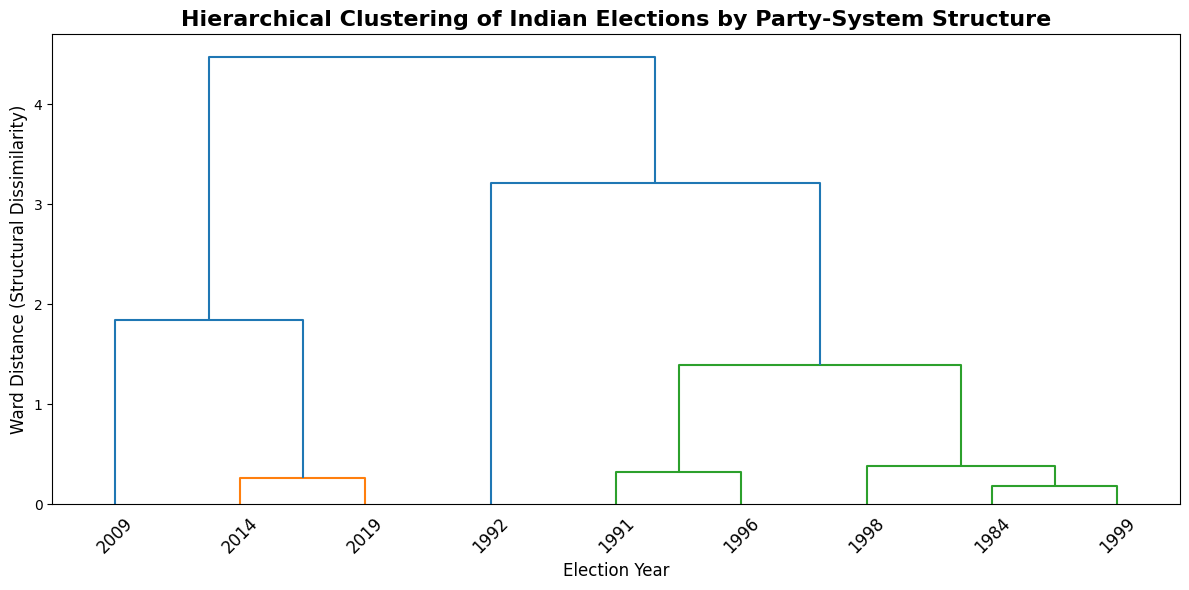

In [ ]:


# 1. Calculate Average Fragmentation per election year
year_frag = df_features.groupby('election_year_clean')['fragmentation_index'].mean().reset_index()

# 2. Calculate National Volatility (Pedersen Index) per election year
df_features['abs_vote_swing'] = df_features['vote_swing'].abs()
year_volatility = df_features.groupby('election_year_clean')['abs_vote_swing'].mean().reset_index()
year_volatility.rename(columns={'abs_vote_swing': 'pedersen_index'}, inplace=True)
year_volatility['pedersen_index'] = year_volatility['pedersen_index'] / 2

# 3. Merge into a clean structural metrics dataset
year_metrics = pd.merge(year_frag, year_volatility, on='election_year_clean', how='inner')

# Clean anomalies and set the year as the index
year_metrics = year_metrics.replace([np.inf, -np.inf], np.nan).dropna()
year_metrics.set_index('election_year_clean', inplace=True)

# 4. Standardize the structural metrics
scaler = StandardScaler()
year_scaled = scaler.fit_transform(year_metrics)

# 5. Compute the linkage matrix using Ward's minimum variance method
Z = sch.linkage(year_scaled, method='ward')

# 6. Visualize the structural clustering of historical elections
plt.figure(figsize=(12, 6))
sch.dendrogram(Z, labels=year_metrics.index.astype(int), leaf_rotation=45, color_threshold=sch.linkage(year_scaled, method='ward')[-3, 2]) # Colors the top 3 distinct eras
plt.title("Hierarchical Clustering of Indian Elections by Party-System Structure", fontsize=16, fontweight='bold')
plt.xlabel("Election Year", fontsize=12)
plt.ylabel("Ward Distance (Structural Dissimilarity)", fontsize=12)
plt.tight_layout()
plt.show()

---

## 8.3 Feature importance and political interpretation

### 8.3.1 SHAP / permutation importance for ML models

Tree-based models are often criticized as uninterpretable. To solve this, we compute SHAP (SHapley Additive exPlanations) values. Rooted in cooperative game theory, SHAP calculates the exact marginal contribution of each variable to the prediction for every single candidate, allowing us to see why the model made its decision.

The SHAP value $\phi_i$ for feature $i$ given a model $f$ and feature set $N$ is:$$\phi_i(f, x) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (|N| - |S| - 1)!}{|N|!} \left[ f(S \cup \{i\}) - f(S) \right]$$(Where $S$ is a subset of features not including $i$, and the equation calculates the weighted average marginal contribution of adding $i$ to the model).

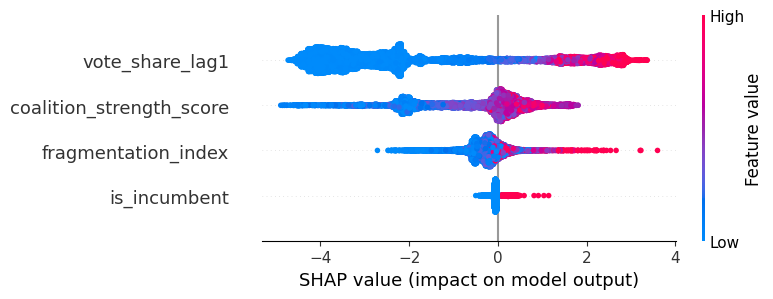

In [13]:
import shap

# We compute SHAP values for the optimized XGBoost model
explainer = shap.TreeExplainer(xgb_tuned.best_estimator_)
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize feature impacts globally
shap.summary_plot(shap_values, X_test, plot_type="dot")